<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA-ML-DL-Projects/blob/main/AI_BASED_MEDICAL_INSURANCE_COST_PREDICTION_SYSTEM(PROJECT_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

Medical insurance companies need to estimate the cost of insurance accurately based on a person's health and lifestyle factors. Factors such as age, BMI, smoking habits, income, exercise frequency, and chronic diseases can significantly affect medical expenses. However, manually predicting insurance costs is difficult because these factors are interrelated and influence costs differently.

The aim of this project is to develop an AI-Based Medical Insurance Cost Prediction System using data analysis, machine learning, and deep learning techniques. The system will analyze customer information, identify important factors affecting insurance costs, and predict the expected medical insurance expenses. This prediction can help insurance providers make better pricing decisions and assist individuals in understanding their potential insurance costs.


# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

In [ ]:
df=pd.read_csv('/content/medical_insurance_cost_dataset_55000_rows.csv')
df

,age,sex,bmi,children,smoker,region,exercise_days_per_week,chronic_disease,annual_income,occupation_type,marital_status,alcohol_consumption,sleep_hours,insurance_cost
0,56,Male,29.4,0,No,East,1,No,1243010,Private,Divorced,Occasionally,9.5,31051.90
1,46,Female,35.8,3,Yes,West,3,No,1521082,Retired,Divorced,Never,5.0,58227.55
2,32,Female,20.8,1,Yes,South,7,No,922274,Government,Married,Frequently,8.6,37017.69
3,60,Female,29.1,5,No,North,1,Yes,723348,Self-Employed,Married,Occasionally,4.9,42209.91
4,25,Female,21.3,0,No,East,3,No,1026626,Government,Divorced,Occasionally,7.2,17025.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54995,31,Female,33.5,4,No,South,3,Yes,579217,Student,Married,Frequently,5.7,37948.72
54996,46,Male,25.1,1,No,North,3,No,2312747,Private,Married,Frequently,7.5,29751.51
54997,34,Female,23.0,2,No,North,4,No,307925,Retired,Single,Never,4.7,17834.11
54998,18,Female,25.5,0,No,West,7,No,938114,Private,Single,Never,6.5,20066.93


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     55000 non-null  int64  
 1   sex                     55000 non-null  object 
 2   bmi                     55000 non-null  float64
 3   children                55000 non-null  int64  
 4   smoker                  55000 non-null  object 
 5   region                  55000 non-null  object 
 6   exercise_days_per_week  55000 non-null  int64  
 7   chronic_disease         55000 non-null  object 
 8   annual_income           55000 non-null  int64  
 9   occupation_type         55000 non-null  object 
 10  marital_status          55000 non-null  object 
 11  alcohol_consumption     55000 non-null  object 
 12  sleep_hours             55000 non-null  float64
 13  insurance_cost          55000 non-null  float64
dtypes: float64(3), int64(4), object(7)
mem

In [ ]:
df.shape

(55000, 14)

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
exercise_days_per_week,0
chronic_disease,0
annual_income,0
occupation_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'exercise_days_per_week', 'chronic_disease', 'annual_income',
       'occupation_type', 'marital_status', 'alcohol_consumption',
       'sleep_hours', 'insurance_cost'],
      dtype='object')

In [ ]:
target='insurance_cost'

In [ ]:
df[target].value_counts()

,count
insurance_cost,
5000.00,14
22958.14,3
25925.32,2
51420.29,2
32480.13,2
...,...
33786.13,1
77338.41,1
50252.96,1


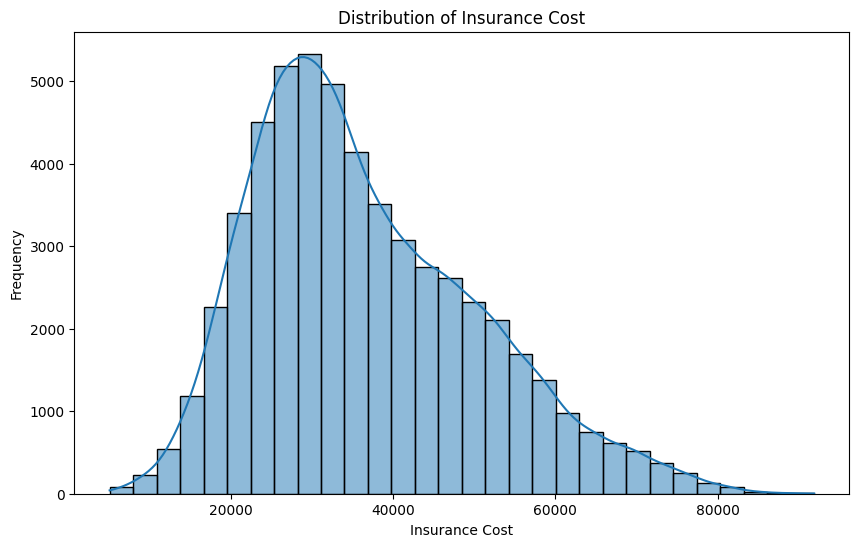

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["insurance_cost"], bins=30, kde=True)
plt.title("Distribution of Insurance Cost")
plt.xlabel("Insurance Cost")
plt.ylabel("Frequency")
plt.show()

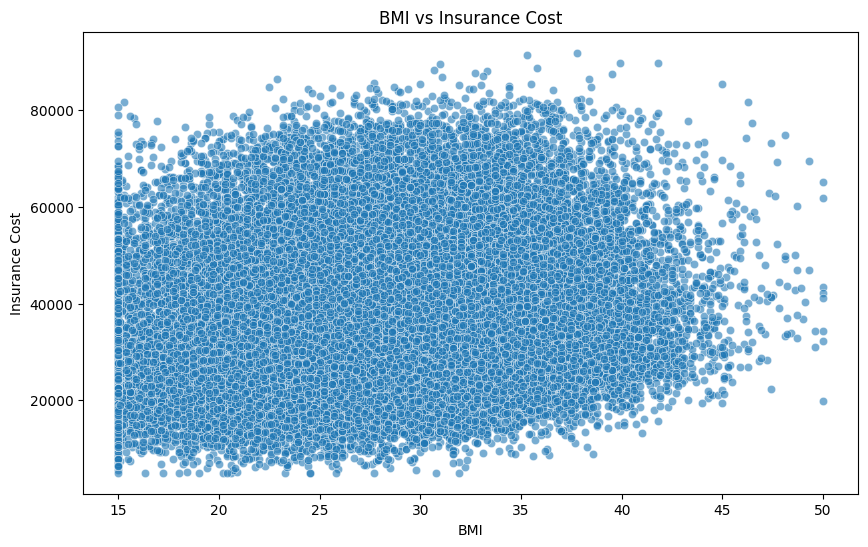

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="insurance_cost", alpha=0.6)
plt.title("BMI vs Insurance Cost")
plt.xlabel("BMI")
plt.ylabel("Insurance Cost")
plt.show()

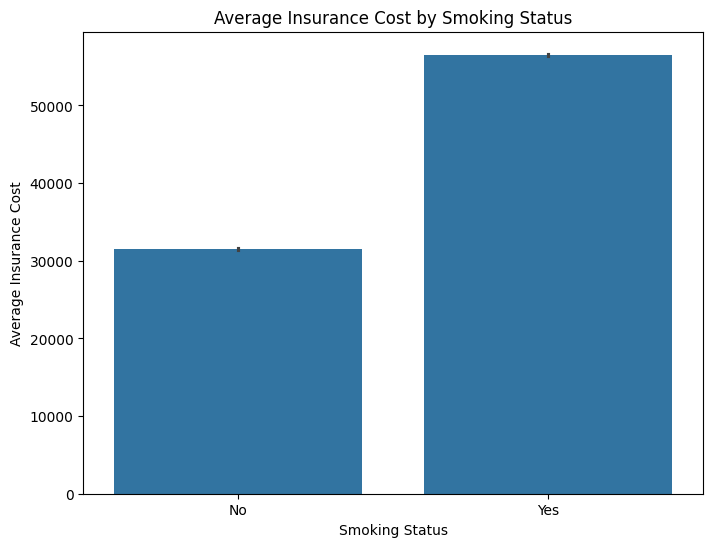

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="smoker", y="insurance_cost")
plt.title("Average Insurance Cost by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Cost")
plt.show()

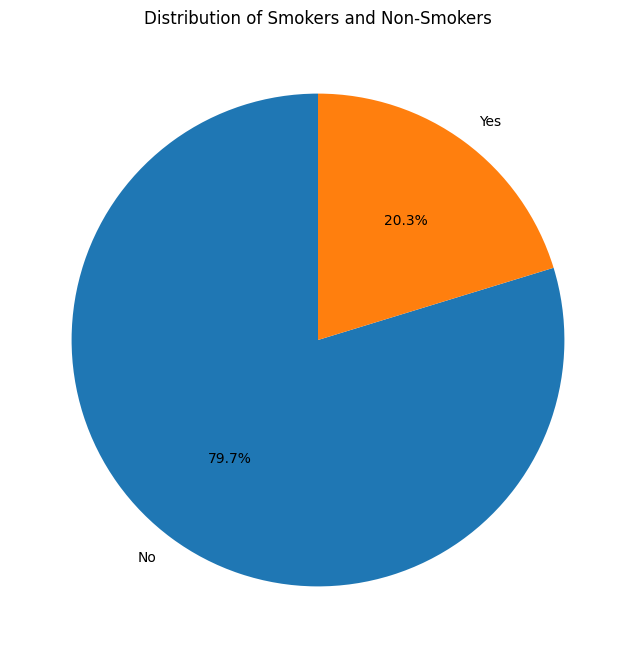

In [ ]:
smoker_counts = df["smoker"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    smoker_counts,
    labels=smoker_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Smokers and Non-Smokers")
plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['age', 'bmi', 'children', 'exercise_days_per_week', 'annual_income',
       'sleep_hours', 'insurance_cost'],
      dtype='object')

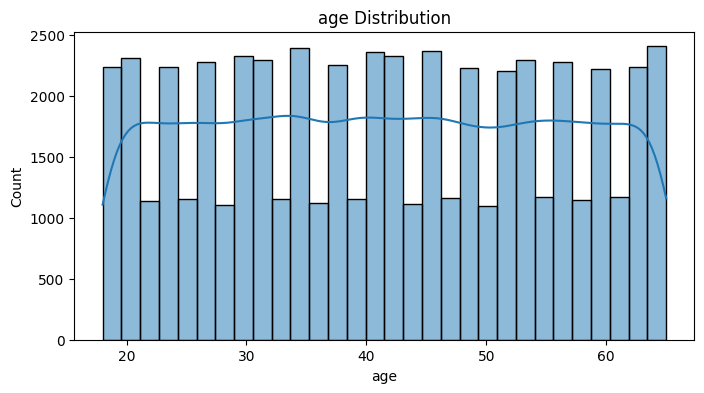

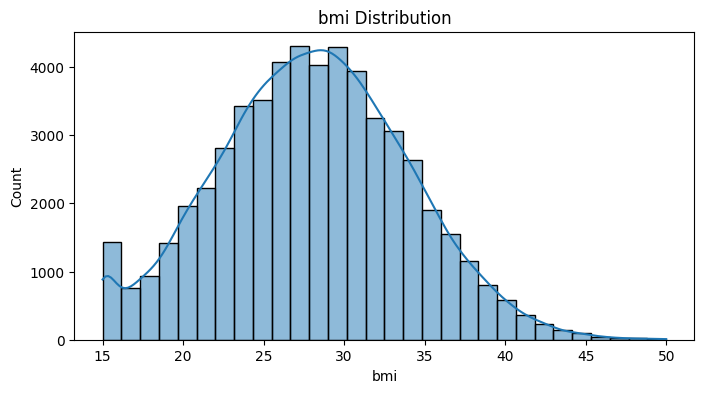

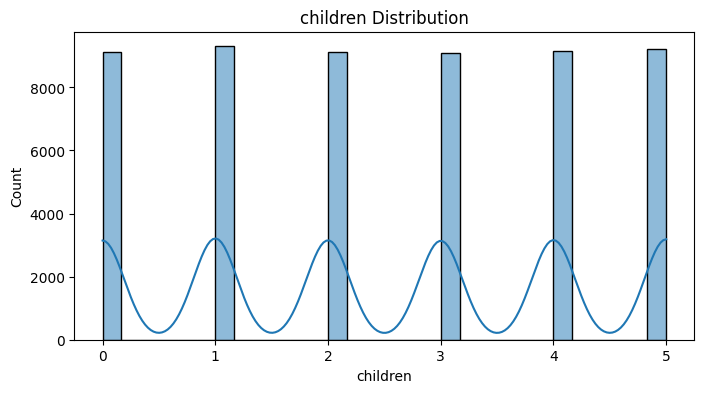

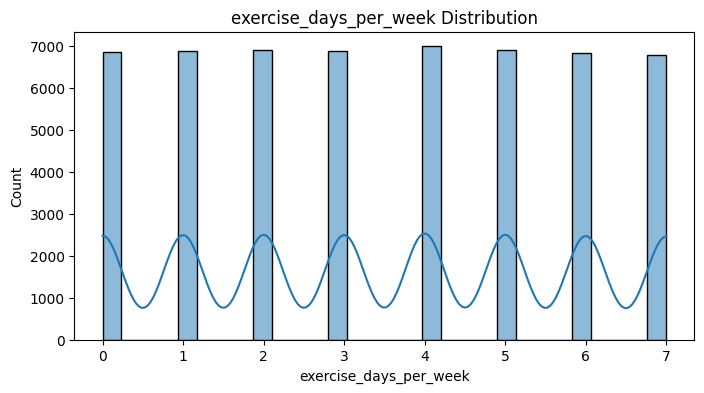

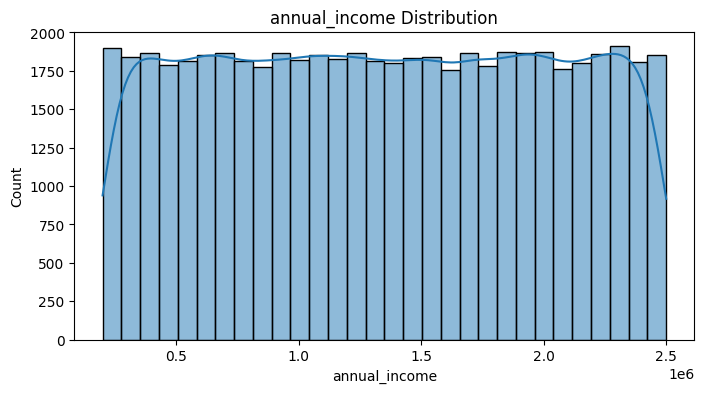

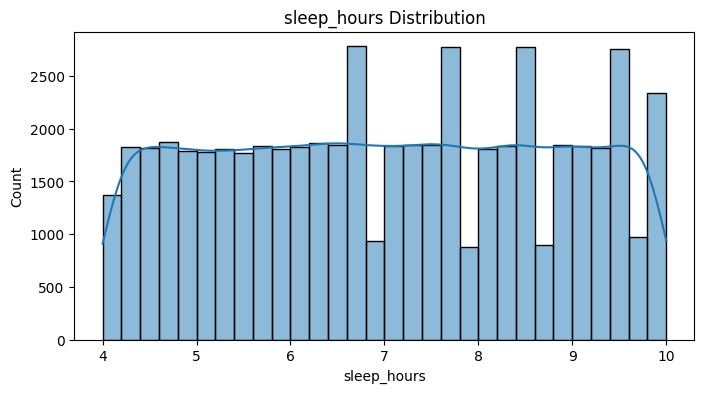

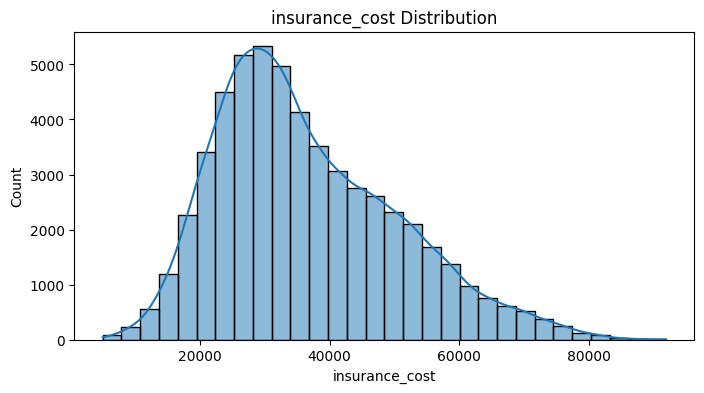

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['sex', 'smoker', 'region', 'chronic_disease', 'occupation_type',
       'marital_status', 'alcohol_consumption'],
      dtype='object')

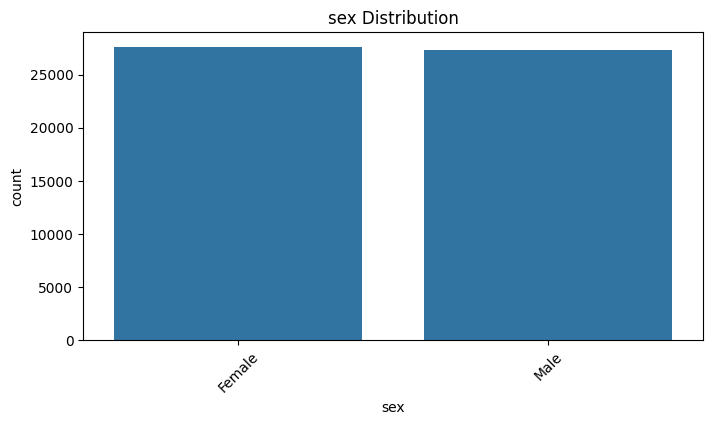

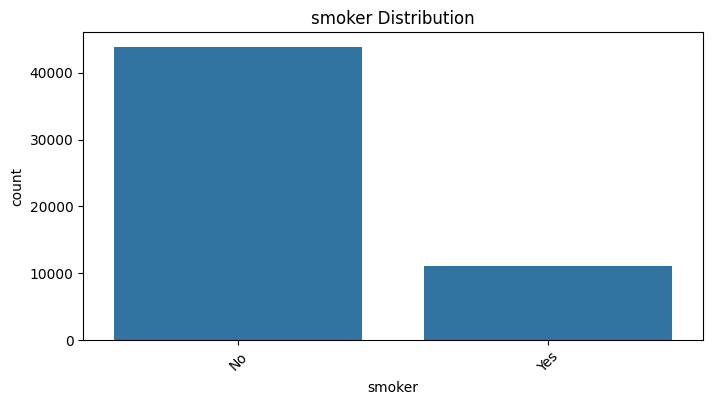

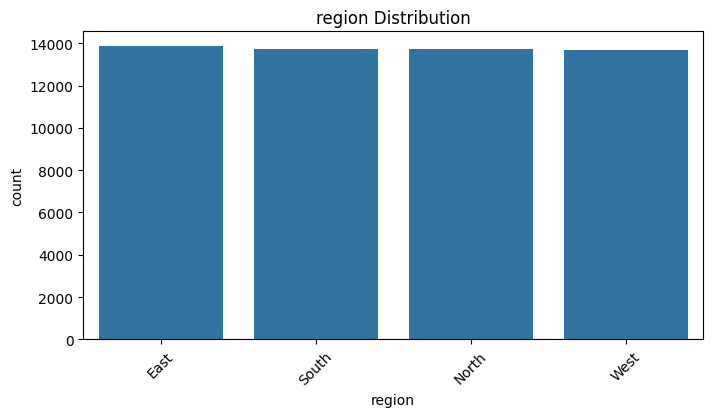

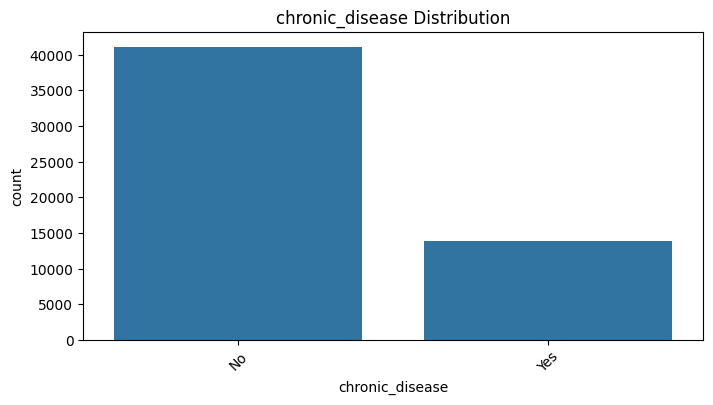

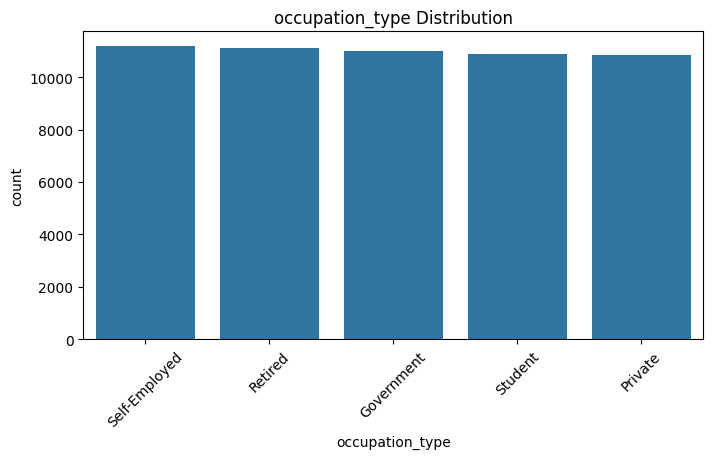

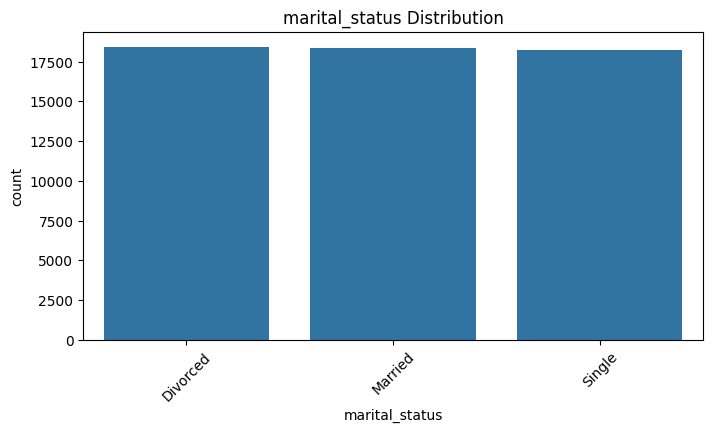

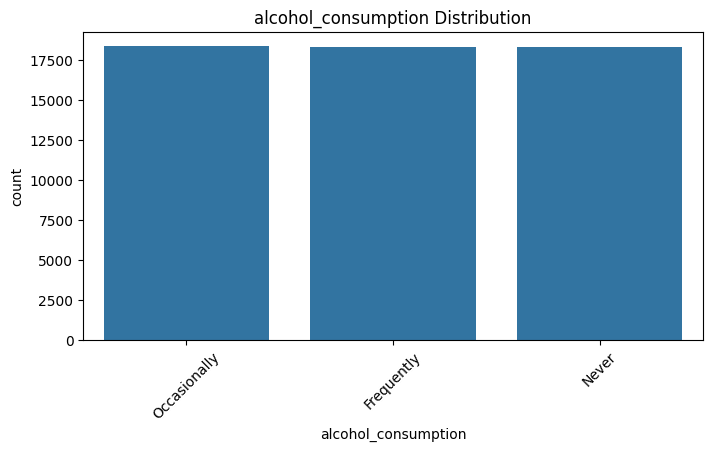

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     55000 non-null  int64  
 1   sex                     55000 non-null  object 
 2   bmi                     55000 non-null  float64
 3   children                55000 non-null  int64  
 4   smoker                  55000 non-null  object 
 5   region                  55000 non-null  object 
 6   exercise_days_per_week  55000 non-null  int64  
 7   chronic_disease         55000 non-null  object 
 8   annual_income           55000 non-null  int64  
 9   occupation_type         55000 non-null  object 
 10  marital_status          55000 non-null  object 
 11  alcohol_consumption     55000 non-null  object 
 12  sleep_hours             55000 non-null  float64
 13  insurance_cost          55000 non-null  float64
dtypes: float64(3), int64(4), object(7)
mem

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['sex']=le.fit_transform(df['sex'])
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])
df['chronic_disease']=le.fit_transform(df['chronic_disease'])
df['occupation_type']=le.fit_transform(df['occupation_type'])
df['marital_status']=le.fit_transform(df['marital_status'])

In [ ]:
print(df['alcohol_consumption'].unique())

['Occasionally' 'Never' 'Frequently']


In [ ]:
df['alcohol_consumption'].replace(['Occasionally','Never','Frequently'],[0,1,2],inplace=True)

/tmp/ipykernel_3854/3640287570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_consumption'].replace(['Occasionally','Never','Frequently'],[0,1,2],inplace=True)
/tmp/ipykernel_3854/3640287570.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['alcohol_consumption'].replace(['Occa

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     55000 non-null  int64  
 1   sex                     55000 non-null  int64  
 2   bmi                     55000 non-null  float64
 3   children                55000 non-null  int64  
 4   smoker                  55000 non-null  int64  
 5   region                  55000 non-null  int64  
 6   exercise_days_per_week  55000 non-null  int64  
 7   chronic_disease         55000 non-null  int64  
 8   annual_income           55000 non-null  int64  
 9   occupation_type         55000 non-null  int64  
 10  marital_status          55000 non-null  int64  
 11  alcohol_consumption     55000 non-null  int64  
 12  sleep_hours             55000 non-null  float64
 13  insurance_cost          55000 non-null  float64
dtypes: float64(3), int64(11)
memory usage:

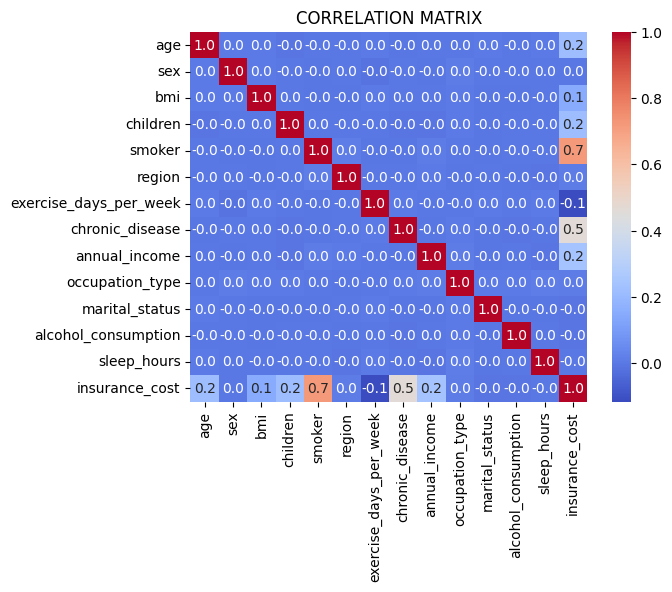

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('CORRELATION MATRIX')
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)['insurance_cost']
print(corr.sort_values(ascending=False))

insurance_cost            1.000000
smoker                    0.717719
chronic_disease           0.461348
annual_income             0.240297
children                  0.215042
age                       0.214348
bmi                       0.147724
occupation_type           0.008504
region                    0.006918
sex                       0.000059
sleep_hours              -0.001997
alcohol_consumption      -0.006700
marital_status           -0.009420
exercise_days_per_week   -0.115432
Name: insurance_cost, dtype: float64


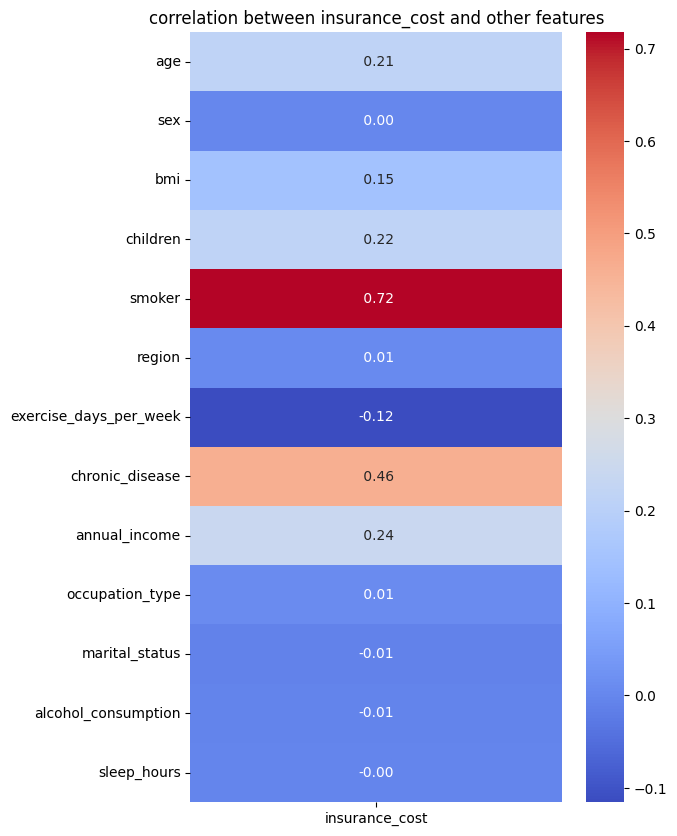

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["insurance_cost"]
status_corr=status_corr.drop("insurance_cost")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between insurance_cost and other features')
plt.show()

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'exercise_days_per_week', 'chronic_disease', 'annual_income',
       'occupation_type', 'marital_status', 'alcohol_consumption',
       'sleep_hours', 'insurance_cost'],
      dtype='object')

In [ ]:
df.drop(['sleep_hours','marital_status', 'alcohol_consumption'],axis=1,inplace=True)

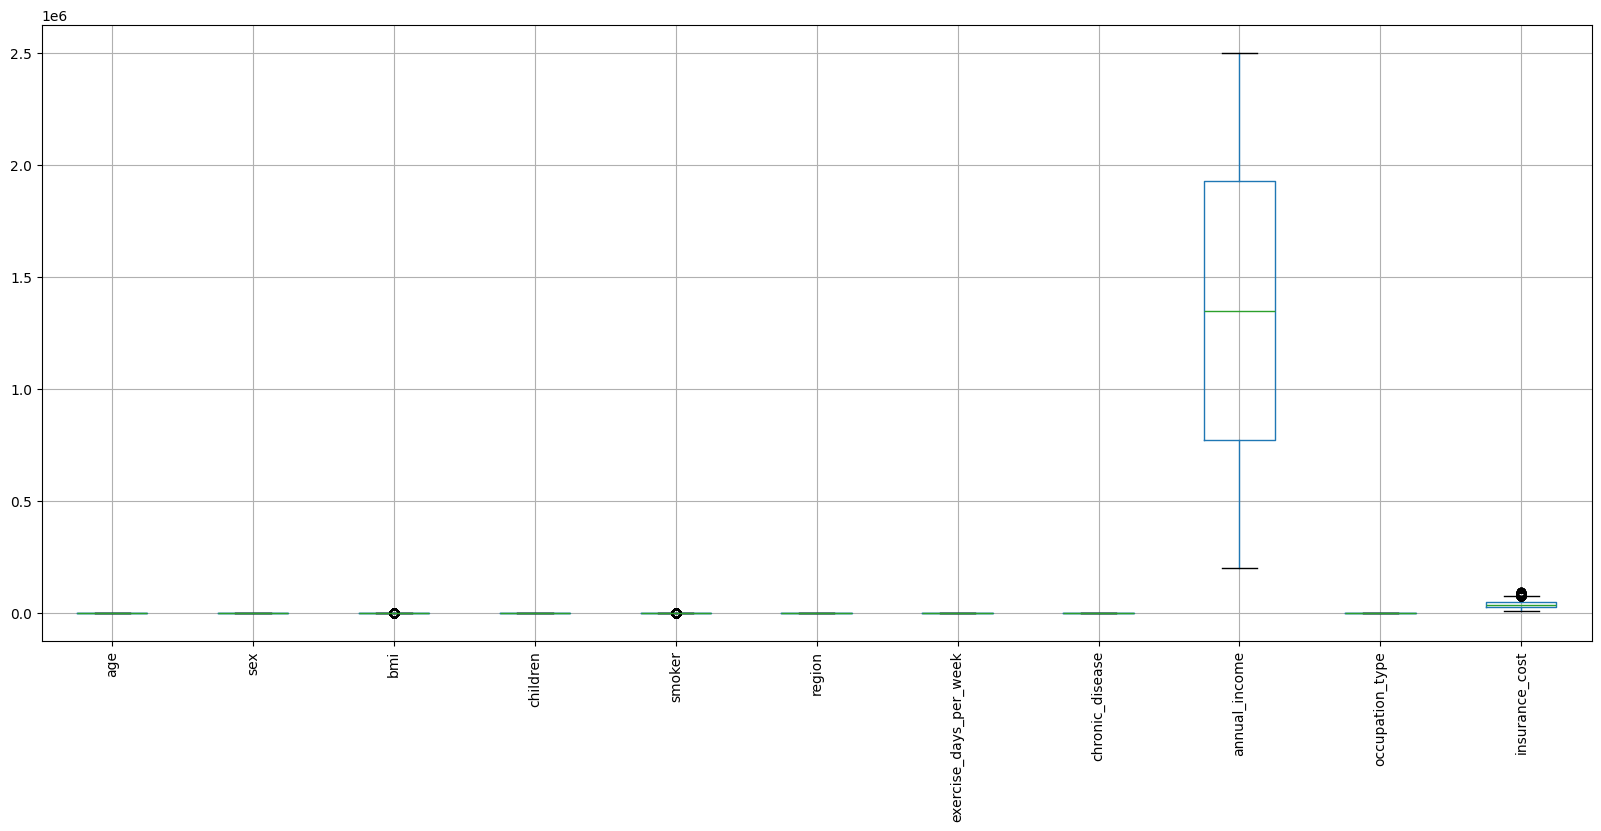

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.shape

(55000, 11)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(43713, 11)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'exercise_days_per_week', 'chronic_disease', 'annual_income',
       'occupation_type', 'insurance_cost'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'exercise_days_per_week', 'chronic_disease', 'annual_income',
       'occupation_type']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

# **MACHINE LEARNING**

In [ ]:
#LINEAR REGRESSION

x=df[['age', 'sex', 'bmi', 'children', 'smoker', 'region',
       'exercise_days_per_week', 'chronic_disease', 'annual_income',
       'occupation_type']]
y=df['insurance_cost']

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.83


In [ ]:
#DECISION TREE

from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.63


In [ ]:
#SVR(SVM)

from sklearn.svm import SVR
model=SVR(kernel="poly",degree=8)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.05


In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.81


In [ ]:
# GRADIENTBOOSTER
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
gb_model = GradientBoostingRegressor(random_state=42)

# Train model
gb_model.fit(x_train, y_train)

# Predict
y_pred_gb = gb_model.predict(x_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R² Score: 0.8270111298185518
MAE: 3233.1931350597706
RMSE: 4054.5797215552757


In [ ]:
# ADABOOST

from sklearn.ensemble import AdaBoostRegressor

model=AdaBoostRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.79


In [ ]:
# XGBOOST

from  xgboost import XGBRegressor
model=XGBRegressor()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.81


# **K-FOLD CROSS VALIDATION**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop('insurance_cost', axis=1)
y = df['insurance_cost']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

best_r2 = -np.inf
best_fold = -1

best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("R² Score:", r2)
    print("RMSE:", rmse)

    if r2 > best_r2:

        best_r2 = r2
        best_fold = fold

        best_X_train = X_train
        best_y_train = y_train

        best_X_test = X_test
        best_y_test = y_test

        best_y_pred = y_pred

print(f"\nBest Fold: {best_fold} with R² Score: {best_r2}")


Fold 1
R² Score: 0.831641314538096
RMSE: 3992.4901571953924

Fold 2
R² Score: 0.8292507654841687
RMSE: 4018.805669447722

Fold 3
R² Score: 0.8268737397067449
RMSE: 4022.5564539944407

Fold 4
R² Score: 0.8337872538741419
RMSE: 3994.309495421517

Fold 5
R² Score: 0.8293102707482254
RMSE: 4011.1441869336654

Best Fold: 4 with R² Score: 0.8337872538741419


In [ ]:
model=LinearRegression()
model.fit(best_X_train,best_y_train)
print("Linear Regression:",model.score(best_X_test,best_y_test))

Linear Regression: 0.8337872538741419


In [ ]:
model=DecisionTreeRegressor()
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.6235970651810172


In [ ]:
model=SVR()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.06122107508593022


In [ ]:
model=RandomForestRegressor()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.8147249661890786


In [ ]:
model=GradientBoostingRegressor(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.8288356431283195


In [ ]:
model=AdaBoostRegressor()
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.796212413943131


In [ ]:
model=XGBRegressor()
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.8184455733227475


# **DEEP LEARNING**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# Scale the data for deep learning
scaler_dl = MinMaxScaler()
x_train_scaled_dl = scaler_dl.fit_transform(best_X_train)
x_test_scaled_dl = scaler_dl.transform(best_X_test)

# Model
model = Sequential()
model.add(Dense(110, input_shape=(x_train_scaled_dl.shape[1],), activation='relu'))  # Hidden Layer 1
model.add(Dense(44, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1))

# Compile with regression metrics
model.compile(optimizer=Adam(learning_rate=0.001), # Adjusted learning rate for better convergence
              loss='mean_squared_error')

# Train
model.fit(x_train_scaled_dl, best_y_train, epochs=50, batch_size=32, verbose=0) # Increased epochs and added batch_size

# Predict
y_pred = model.predict(x_test_scaled_dl)

# Calculate MSE and MAE
mse = mean_squared_error(best_y_test, y_pred)
mae = mean_absolute_error(best_y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Squared Error: 15984487.679565258
Mean Absolute Error: 3203.0056389994065


# **CONCLUSION**

This project developed an AI-based medical insurance cost prediction system using exploratory data analysis, machine learning, and deep learning techniques. The models were trained using customer information such as age, BMI, smoking habits, income, and other lifestyle factors to predict insurance costs accurately.

Among the machine learning models, Linear Regression gave the best performance with an R² score of 0.8338, followed by Gradient Boosting and XGBoost. The deep learning model also provided good predictions with low error values. The results show that AI techniques can effectively estimate medical insurance costs and can help insurance companies make better pricing decisions while helping customers understand their expected insurance expenses.


# **FUTURE SCOPE**

In the future, this project can be improved by using larger real-world healthcare and insurance datasets to increase prediction accuracy and make the system more reliable. Additional factors such as medical history, geographic location, occupation risks, and lifestyle habits can also be included to build a more comprehensive prediction model.

The system can further be integrated into a web or mobile application that provides real-time insurance cost estimates to users. Advanced deep learning techniques and explainable AI methods can also be implemented to improve prediction performance and help insurance companies understand the key factors influencing insurance costs.